In [61]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [62]:
CV1_PATH = r"D:\programming\rPPg\cv_1\cv1_output.json"

with open(CV1_PATH, "r") as f:
    data = json.load(f)

subjects = data["subjects"]

Extract Green Signals

In [63]:
subject = list(subjects.values())[0] #select the first subject 

forehead = subject["per_frame_rgb"]["forehead"] #select the forehead region data
#reason: forehead gives cleanest signal among all the regions
time = np.array(forehead["time_seconds"]) #time in seconds for each frame
G = np.array(forehead["G_per_frame"]) #G channel value for each frame
#reason: rPPG works best in the green channel

Plot the signal

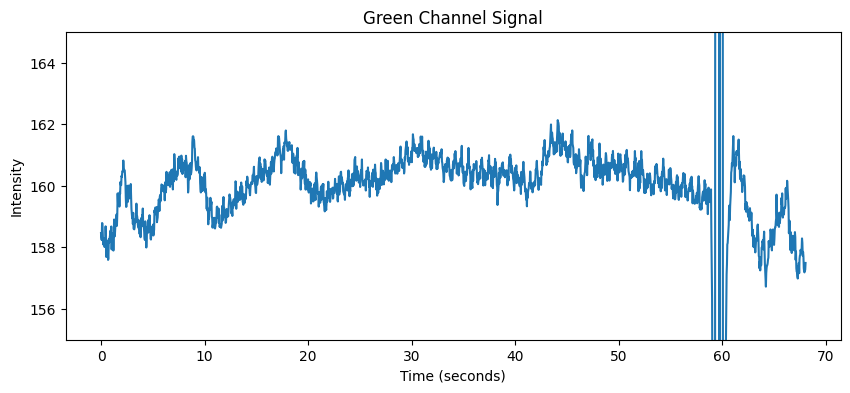

In [64]:
plt.figure(figsize=(10,4))
plt.plot(time, G)
plt.title("Green Channel Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity")
plt.ylim(155,165)
plt.show()

Interpretation:

0-58: Signal is Stable, healthy rPPG

Around 59-61: Huge spikes, drift detected

Possible reasons- subject moved, lightening changes, ROI shifted, camera adjustment 

In [65]:
#Frame rate - how many frames are captured per second.
fps = 1 / np.mean(np.diff(time))
print(f"Frame Rate: {fps:.2f} fps") 

Frame Rate: 29.25 fps


Frame rate is around 30fps, typical for video recordings

In [66]:
window_size = 5 # sliding window analysis with a window of 5 seconds
step = 2.5 # step size for the sliding window, allowing for 50% overlap

Reason: Drift doesn't happen in whole window, so we analyze local segments

In [67]:
window_frame = int(window_size * fps) # number of frames in each window
step_frame = int(step * fps) # number of frames to step for the sliding window
print(f"Window size in frames: {window_frame}, Step size in frames: {step_frame}")

Window size in frames: 146, Step size in frames: 73


In [68]:
drift_windows = []
#Each window will produce information like start_time, variance, drift_flag

In [69]:
for start in range(0, len(G) - window_frame, step_frame):
    segment = G[start:start + window_frame] # extract 5s chunk of signal
    variance = np.var(segment) #measures signal fluctuations
    drift = variance > 2 #example threshold 
    drift_windows.append({
        "start_time": float(time[start]),
        "end_time": float(time[start + window_frame]),
        "variance": float(variance),
        "drift": drift
    })#shows drift detected around start_time with __var and if drift is True/False

In [70]:
for w in drift_windows:
    if w["drift"]:
        print(w)

{'start_time': 54.9142, 'end_time': 59.9064, 'variance': 31.758930901454775, 'drift': True}
{'start_time': 57.4103, 'end_time': 62.4025, 'variance': 51.78786727386796, 'drift': True}
{'start_time': 59.9064, 'end_time': 64.8986, 'variance': 20.35959741099689, 'drift': True}


These windows correspond to large spikes as seen in signal

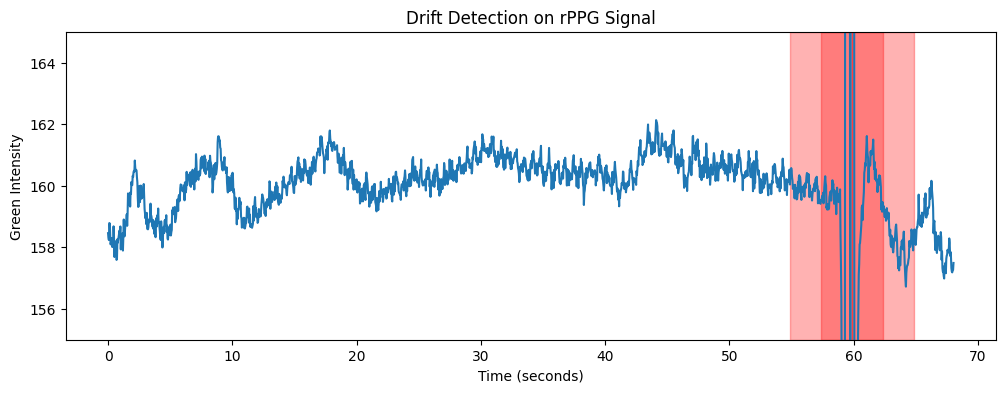

In [77]:
plt.figure(figsize=(12,4))
plt.plot(time, G, label="Green Signal")
plt.ylim(155,165)
#To highlight drift periods
for w in drift_windows:
    if w["drift"]:
        start = w["start_time"]
        end = w["end_time"]
        #Highlight the drift period with a red shaded area
        plt.axvspan(start, end, color='red', alpha=0.3)

plt.title("Drift Detection on rPPG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Green Intensity")
plt.show()

Blue line - Green channel rPPG signal G(t) extracted from forehead
Red shaded - Drift Detected
